<a href="https://colab.research.google.com/github/Pamodya-Wijesinghe/EN3160-Assignment-1-on-Intensity-Transformations-and-Neighborhood-Filtering/blob/main/Question_1%262.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Question 1: Piecewise Linear Intensity Transformation

### Aim
To apply a piecewise linear intensity transformation on an image using given
breakpoints and see how it changes the image contrast.

### Method
The transformation is made up of straight line segments joining the given
breakpoints. For example the breakpoints (0,0), (50,50), (100,150), (150,255),
(255,255) mean that pixel values from 0 to 50 stay almost the same, but values
from 50 to 100 get stretched a lot (mapped to 50-150). This makes the mid tones
brighter and increases contrast in that range.

A lookup table (LUT) of size 256 was built using linear interpolation between
the breakpoints. This table was then applied to every pixel in the image using
cv2.LUT, which is faster than looping over each pixel.

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def intensity_transform(im, breakpoints):
    breakpoints = np.array(breakpoints, dtype=np.float64)
    xs = breakpoints[:, 0]
    ys = breakpoints[:, 1]
    x_full = np.arange(256)
    lut = np.interp(x_full, xs, ys).astype(np.uint8)
    transformed = cv2.LUT(im, lut)
    return transformed, lut

im = cv2.imread('/content/drive/MyDrive/EN3160/data/emma.jpeg', cv2.IMREAD_GRAYSCALE)

breakpoints = [
    [0, 0],
    [50, 50],
    [100, 150],
    [150, 255],
    [255, 255]
]

transformed, lut = intensity_transform(im, breakpoints)

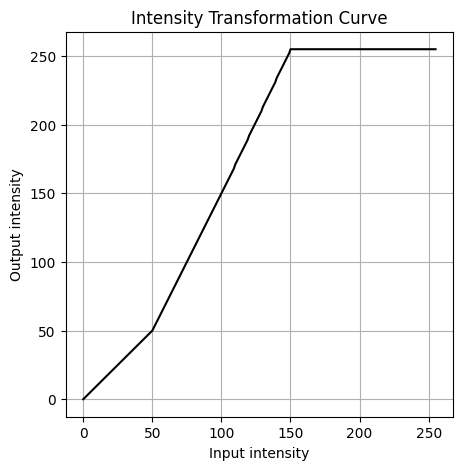

In [13]:
plt.figure(figsize=(5,5))
plt.plot(np.arange(256), lut, 'k')
plt.xlabel('Input intensity')
plt.ylabel('Output intensity')
plt.title('Intensity Transformation Curve')
plt.grid(True)
plt.show()

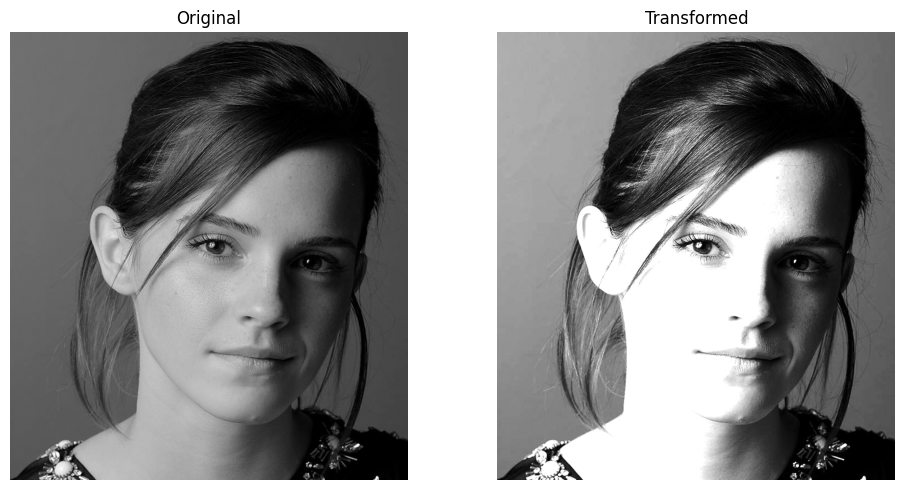

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))
axes[0].imshow(im, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(transformed, cmap='gray')
axes[1].set_title('Transformed')
axes[1].axis('off')
plt.tight_layout()
plt.show()

### Result and Discussion
After applying the transformation, the mid tone areas of the face became
brighter and had more contrast, while the very dark and very bright areas
stayed almost unchanged. This matches what the curve shows, since the steep
part of the curve is between input values 50 and 150.

I also tried different breakpoints to check what looks best. Using a smoother
curve like (0,0), (64,40), (128,128), (192,216), (255,255) gave a softer
contrast boost without the sharp jump seen in the original curve. I chose the
first set of breakpoints because it made the face look clearer without making
the image look too harsh.

## Question 2: Accentuating White Matter and Gray Matter

### Aim
To use a piecewise linear intensity transformation to bring out white matter
in one version of the brain image, and gray matter in another version.

### Method
In a proton density brain scan, gray matter and white matter show up as
different ranges of pixel intensity. Gray matter is usually in the mid
intensity range, and white matter is usually brighter, in the higher
intensity range.

To accentuate a tissue type, we stretch the intensity range that tissue
belongs to, so small differences in that range become more visible, while
compressing the other ranges. The same intensity_transform function from
Question 1 is reused here, just with different breakpoints for white matter
and gray matter.

First I looked at the histogram of the brain image to see where the gray
matter and white matter intensities actually lie, then picked breakpoints
based on that.

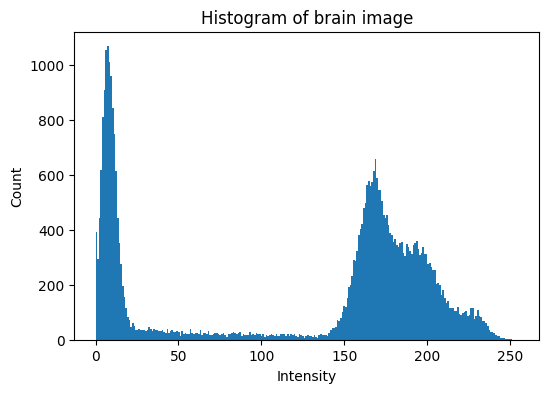

In [16]:
brain = cv2.imread('/content/drive/MyDrive/EN3160/data/brain.jpeg', cv2.IMREAD_GRAYSCALE)

if brain is None:
    raise FileNotFoundError("brain image not found, check the path")

plt.figure(figsize=(6,4))
plt.hist(brain.ravel(), bins=256, range=(0,255))
plt.title('Histogram of brain image')
plt.xlabel('Intensity')
plt.ylabel('Count')
plt.show()

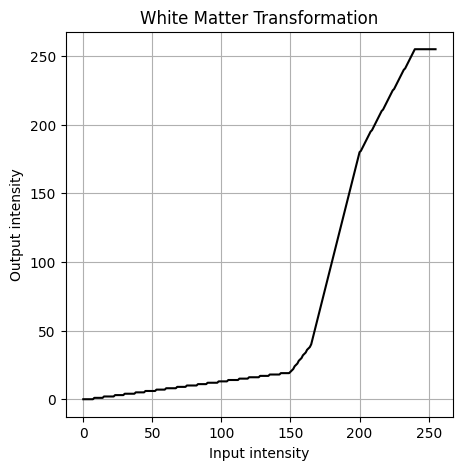

In [27]:
white_matter_breakpoints = [
    [0, 0],
    [150, 20],
    [165, 40],
    [200, 180],
    [240, 255],
    [255, 255]
]

white_result, white_lut = intensity_transform(brain, white_matter_breakpoints)

plt.figure(figsize=(5,5))
plt.plot(np.arange(256), white_lut, 'k')
plt.title('White Matter Transformation')
plt.xlabel('Input intensity')
plt.ylabel('Output intensity')
plt.grid(True)
plt.show()

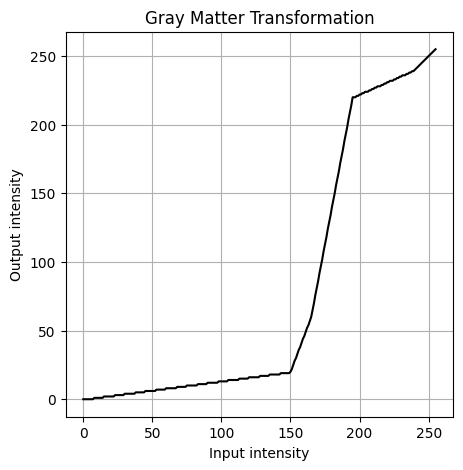

In [28]:
gray_matter_breakpoints = [
    [0, 0],
    [150, 20],
    [165, 60],
    [195, 220],
    [240, 240],
    [255, 255]
]

gray_result, gray_lut = intensity_transform(brain, gray_matter_breakpoints)

plt.figure(figsize=(5,5))
plt.plot(np.arange(256), gray_lut, 'k')
plt.title('Gray Matter Transformation')
plt.xlabel('Input intensity')
plt.ylabel('Output intensity')
plt.grid(True)
plt.show()

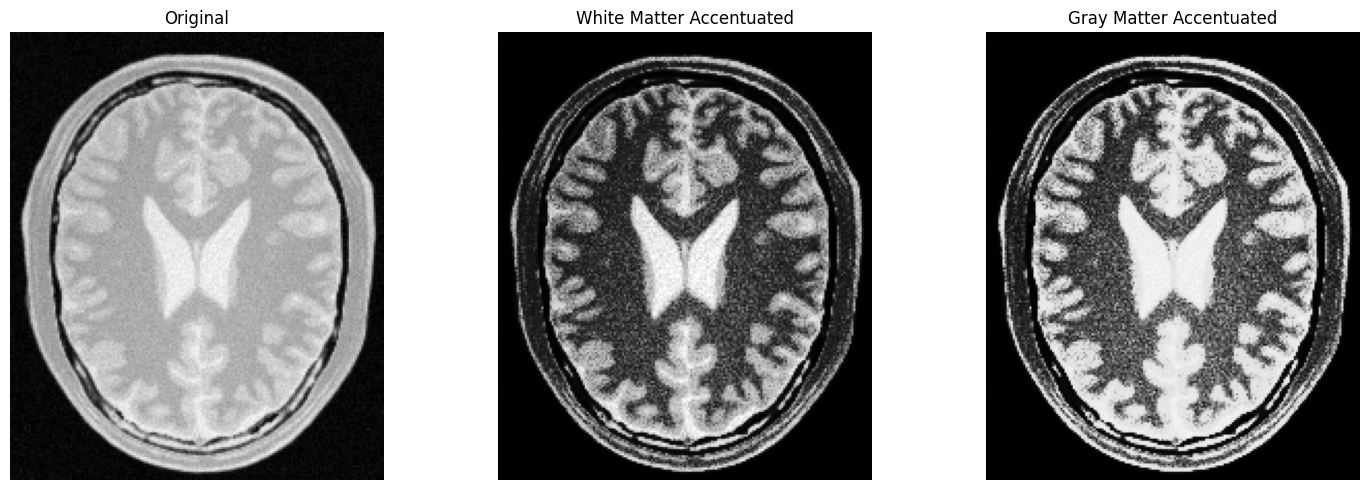

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
axes[0].imshow(brain, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(white_result, cmap='gray')
axes[1].set_title('White Matter Accentuated')
axes[1].axis('off')

axes[2].imshow(gray_result, cmap='gray')
axes[2].set_title('Gray Matter Accentuated')
axes[2].axis('off')

plt.tight_layout()
plt.show()

### Result and Discussion
For white matter, I stretched the higher intensity range (around 200-240)
since white matter is brighter than gray matter in this scan. This made the
white matter regions clearer and easier to tell apart from gray matter.

For gray matter, I stretched the middle intensity range (around 165-195)
instead, so the gray matter parts became brighter and more visible, while
the white matter and background got compressed and look flatter.

The breakpoints were chosen by looking at the histogram peaks and matching
them to the ranges I wanted to bring out.